<font size="2">

## Practice Activity: Core AIML Concepts

**Topics covered in this notebook:**
- Linear Regression (underfitting / overfitting demonstration)
- Logistic Regression
- Decision Tree (bias-variance tradeoff)
- Random Forest (ensemble method to reduce overfitting)
- Bias-Variance decomposition visualization
- Cross Validation (k-fold)
- Overfitting vs Underfitting identification
- Feature Scaling (StandardScaler)
- Label Encoding & One-Hot Encoding

**Goals:**
1. Understand how model complexity affects bias and variance
2. Compare single decision tree vs random forest performance
3. Apply cross-validation to evaluate model stability
4. Encode categorical data using appropriate methods
5. Scale features and observe the effect on model training

**Dataset used:** Synthetic classification & regression data, Iris dataset

</font>

<font size="2">

### 1. Library Imports and Configuration
Run the cell below to import all required libraries.

</font>

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

# Datasets
from sklearn.datasets import make_regression, load_iris, make_classification

# Settings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


<font size="2">

### 2. Feature Scaling - Why and How?
Feature scaling normalizes the range of independent variables. Run the cell below to see before/after scaling.

</font>

In [2]:
# Create sample data with different scales
data = pd.DataFrame({
    'Age': [25, 30, 35, 40, 45, 50, 55, 60],
    'Salary': [30000, 45000, 60000, 80000, 100000, 120000, 150000, 180000],
    'Experience': [1, 3, 5, 7, 9, 11, 13, 15]
})

print("Original Data:")
print(data.head())
print(f"\nBefore Scaling - Mean & Std:")
print(f"Age: mean={data['Age'].mean():.1f}, std={data['Age'].std():.1f}")
print(f"Salary: mean={data['Salary'].mean():.1f}, std={data['Salary'].std():.1f}")

# Apply StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

print(f"\nAfter Scaling - Mean & Std:")
print(f"Age: mean={scaled_df['Age'].mean():.2f}, std={scaled_df['Age'].std():.2f}")
print(f"Salary: mean={scaled_df['Salary'].mean():.2f}, std={scaled_df['Salary'].std():.2f}")

print("\n✅ Features now have mean=0 and std=1")

Original Data:
   Age  Salary  Experience
0   25   30000           1
1   30   45000           3
2   35   60000           5
3   40   80000           7
4   45  100000           9

Before Scaling - Mean & Std:
Age: mean=42.5, std=12.2
Salary: mean=95625.0, std=52197.3

After Scaling - Mean & Std:
Age: mean=0.00, std=1.07
Salary: mean=0.00, std=1.07

✅ Features now have mean=0 and std=1


<font size="2">

### 3. Encoding Categorical Variables
- **Label Encoding**: For ordinal categories (Small < Medium < Large)
- **One-Hot Encoding**: For nominal categories (no order)

</font>

In [3]:
# Sample data
df = pd.DataFrame({
    'Size': ['S', 'M', 'L', 'XL', 'M', 'S', 'L', 'M'],
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Green', 'Blue', 'Red', 'Blue'],
    'Price': [100, 150, 200, 250, 160, 110, 210, 140]
})

print("Original Data:")
print(df)

# Label Encoding (for Size - ordinal)
label_enc = LabelEncoder()
df['Size_Encoded'] = label_enc.fit_transform(df['Size'])
print("\n✅ Label Encoding (Size):")
print(f"Mapping: {dict(zip(df['Size'], df['Size_Encoded']))}")

# One-Hot Encoding (for Color - nominal)
onehot = OneHotEncoder(sparse_output=False)
color_encoded = onehot.fit_transform(df[['Color']])
color_df = pd.DataFrame(color_encoded, columns=[f'Color_{c}' for c in onehot.categories_[0]])
df_final = pd.concat([df, color_df], axis=1)

print("\n✅ One-Hot Encoding (Color):")
print(df_final.head())
print("\nNote: Color column expanded into 3 binary columns (Red, Blue, Green)")

Original Data:
  Size  Color  Price
0    S    Red    100
1    M   Blue    150
2    L  Green    200
3   XL    Red    250
4    M  Green    160
5    S   Blue    110
6    L    Red    210
7    M   Blue    140

✅ Label Encoding (Size):
Mapping: {'S': 2, 'M': 1, 'L': 0, 'XL': 3}

✅ One-Hot Encoding (Color):
  Size  Color  Price  Size_Encoded  Color_Blue  Color_Green  Color_Red
0    S    Red    100             2         0.0          0.0        1.0
1    M   Blue    150             1         1.0          0.0        0.0
2    L  Green    200             0         0.0          1.0        0.0
3   XL    Red    250             3         0.0          0.0        1.0
4    M  Green    160             1         0.0          1.0        0.0

Note: Color column expanded into 3 binary columns (Red, Blue, Green)


<font size="2">

### 4. Linear Regression: Underfitting (High Bias) vs Overfitting (High Variance)

</font>

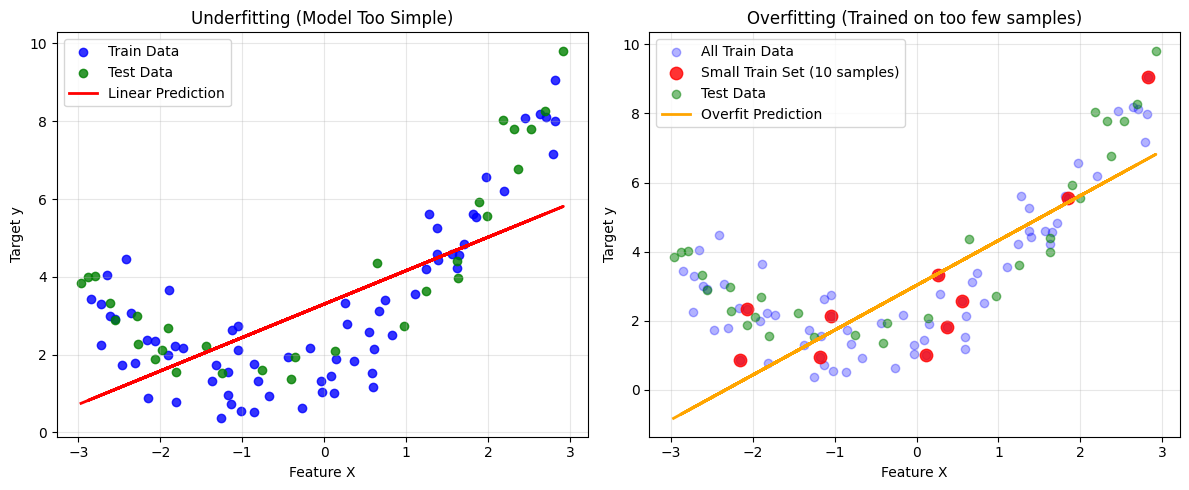

📊 Results:
Underfit Model (Simple Linear) - Test MSE: 3.32
Overfit Model (Small training set) - Test MSE: 4.84

💡 Observation:
- Underfitting: Model is too simple to capture pattern → High Bias
- Overfitting: Model memorized few training points → Fails on new data → High Variance


In [10]:
# Generate synthetic data with non-linear relationship
np.random.seed(42)
X = np.random.rand(100, 1) * 6 - 3  # Range -3 to 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1) * 0.8  # Quadratic relationship

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model 1: Simple Linear (Underfitting)
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)
y_pred_simple = lr_simple.predict(X_test)

# Model 2: For overfitting, we'll train on very few samples (small data = overfit)
# Take only first 10 training samples
X_train_small = X_train[:10]
y_train_small = y_train[:10]

lr_overfit = LinearRegression()
lr_overfit.fit(X_train_small, y_train_small)
y_pred_overfit = lr_overfit.predict(X_test)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Underfitting plot
axes[0].scatter(X_train, y_train, alpha=0.8, label='Train Data', color='blue')
axes[0].scatter(X_test, y_test, alpha=0.8, label='Test Data', color='green')
axes[0].plot(X_test, y_pred_simple, 'r-', linewidth=2, label='Linear Prediction')
axes[0].set_title('Underfitting (Model Too Simple)', fontsize=12)
axes[0].set_xlabel('Feature X')
axes[0].set_ylabel('Target y')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Overfitting plot
axes[1].scatter(X_train, y_train, alpha=0.3, label='All Train Data', color='blue')
axes[1].scatter(X_train_small, y_train_small, alpha=0.8, label='Small Train Set (10 samples)', color='red', s=80)
axes[1].scatter(X_test, y_test, alpha=0.5, label='Test Data', color='green')
axes[1].plot(X_test, y_pred_overfit, 'orange', linewidth=2, label='Overfit Prediction')
axes[1].set_title('Overfitting (Trained on too few samples)', fontsize=12)
axes[1].set_xlabel('Feature X')
axes[1].set_ylabel('Target y')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate errors
mse_simple = mean_squared_error(y_test, y_pred_simple)
mse_overfit = mean_squared_error(y_test, y_pred_overfit)

print(f"📊 Results:")
print(f"Underfit Model (Simple Linear) - Test MSE: {mse_simple:.2f}")
print(f"Overfit Model (Small training set) - Test MSE: {mse_overfit:.2f}")
print(f"\n💡 Observation:")
print(f"- Underfitting: Model is too simple to capture pattern → High Bias")
print(f"- Overfitting: Model memorized few training points → Fails on new data → High Variance")

<font size="2">

### 5. Logistic Regression with k-Fold Cross-Validation

</font>

In [11]:
# Create classification dataset
X_clf, y_clf = make_classification(n_samples=500, n_features=5, 
                                    n_informative=4, n_redundant=1, 
                                    random_state=42)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clf)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

# Logistic Regression with Cross-Validation
log_reg = LogisticRegression()
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.3f}")
print(f"\nMean CV Accuracy: {cv_scores.mean():.3f} (±{cv_scores.std()*2:.3f})")

# Train on full training set
log_reg.fit(X_train, y_train)
test_accuracy = log_reg.score(X_test, y_test)

print(f"\nTest Set Accuracy: {test_accuracy:.3f}")
print("\n✅ Cross-validation gives more reliable performance estimate")

5-Fold Cross-Validation Results:
  Fold 1: 0.713
  Fold 2: 0.613
  Fold 3: 0.725
  Fold 4: 0.613
  Fold 5: 0.675

Mean CV Accuracy: 0.668 (±0.096)

Test Set Accuracy: 0.710

✅ Cross-validation gives more reliable performance estimate


<font size="2">

### 6. Decision Tree Depth: Bias vs Variance

</font>

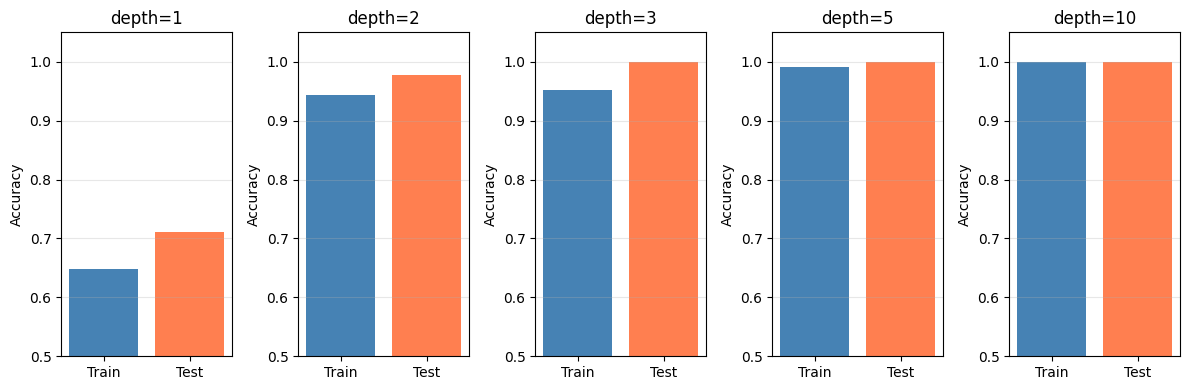

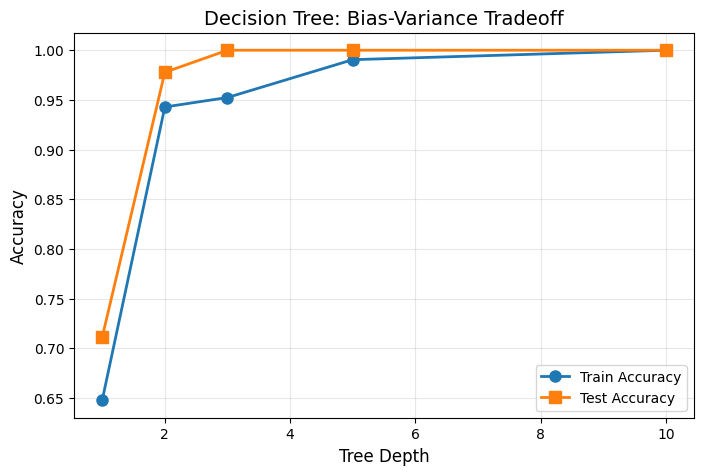

📊 Observations:
  - Depth 1-2: High Bias (Underfitting)
  - Depth 3-5: Best tradeoff (Lowest variance)
  - Depth 10:  High Variance (Overfitting) - Train: 1.000, Test: 1.000


In [20]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

depths = [1, 2, 3, 5, 10]
train_acc = []
test_acc = []

plt.figure(figsize=(12, 4))

for i, depth in enumerate(depths):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc.append(dt.score(X_train, y_train))
    test_acc.append(dt.score(X_test, y_test))
    
    # Plot individual trees
    plt.subplot(1, 5, i+1)
    plt.bar(['Train', 'Test'], [train_acc[-1], test_acc[-1]], color=['steelblue', 'coral'])
    plt.ylim(0.5, 1.05)
    plt.title(f'depth={depth}')
    plt.ylabel('Accuracy')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary plot
plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(depths, test_acc, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Decision Tree: Bias-Variance Tradeoff', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("📊 Observations:")
print(f"  - Depth 1-2: High Bias (Underfitting)")
print(f"  - Depth 3-5: Best tradeoff (Lowest variance)")
print(f"  - Depth 10:  High Variance (Overfitting) - Train: {train_acc[-1]:.3f}, Test: {test_acc[-1]:.3f}")

<font size="2">

### 7. Random Forest (Ensemble) vs Single Decision Tree

</font>

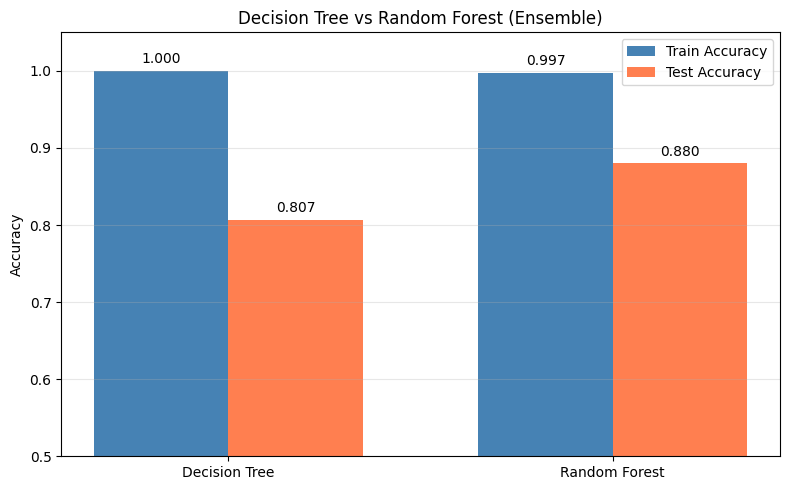

📊 Random Forest vs Decision Tree:
Decision Tree  - Test Accuracy: 0.807
Random Forest  - Test Accuracy: 0.880

✅ Random Forest (ensemble) gives better generalization than single tree


In [24]:
# Noisy dataset
X_noisy, y_noisy = make_classification(n_samples=500, n_features=10,
                                        n_informative=7, n_redundant=3,
                                        flip_y=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_noisy, y_noisy, test_size=0.3, random_state=42)

# Models
dt = DecisionTreeClassifier(max_depth=10, random_state=42)  # Limited depth to avoid extreme overfit
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)

# Train
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Results
dt_train = dt.score(X_train, y_train)
dt_test = dt.score(X_test, y_test)
rf_train = rf.score(X_train, y_train)
rf_test = rf.score(X_test, y_test)

# Visualization
x = ['Decision Tree', 'Random Forest']
train_scores = [dt_train, rf_train]
test_scores = [dt_test, rf_test]

x_pos = np.arange(len(x))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x_pos - width/2, train_scores, width, label='Train Accuracy', color='steelblue')
ax.bar(x_pos + width/2, test_scores, width, label='Test Accuracy', color='coral')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree vs Random Forest (Ensemble)')
ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (train, test) in enumerate(zip(train_scores, test_scores)):
    ax.text(i - width/2, train + 0.01, f'{train:.3f}', ha='center', fontsize=10)
    ax.text(i + width/2, test + 0.01, f'{test:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 Random Forest vs Decision Tree:")
print(f"Decision Tree  - Test Accuracy: {dt_test:.3f}")
print(f"Random Forest  - Test Accuracy: {rf_test:.3f}")
print(f"\n✅ Random Forest (ensemble) gives better generalization than single tree")

<font size="2">

### 8. Key Takeaways

| Concept | Key Insight |
|---------|--------------|
| **Feature Scaling** | StandardScaler makes mean=0, std=1 |
| **Label Encoding** | For ordinal data (S<M<L) |
| **One-Hot Encoding** | For nominal data (colors) |
| **Underfitting** | Model too simple → High Bias |
| **Overfitting** | Too complex or too little data → High Variance |
| **Cross-Validation** | More reliable than single train-test split |
| **Decision Tree Depth** | Controls bias-variance tradeoff |
| **Random Forest** | Ensemble method reduces overfitting |

**✅ Practice Session Complete!**

</font>